In [59]:
import pandas as pd

df = pd.read_csv("students.csv")

print(df.head())

      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  


In [60]:
df.head()

,name,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
0,Alice,88,92,76,80,95,92,4.5,1
1,Bob,42,55,48,50,60,65,1.2,0
2,Charlie,75,70,80,68,88,85,3.0,1
3,Diana,95,98,91,89,97,98,6.0,1
4,Eve,38,42,50,45,55,58,0.8,0


In [61]:
df.shape

(15, 9)

In [62]:
df.dtypes

name                       str
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object

In [63]:
df.describe()

,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
count,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000
mean,65.000000,66.733333,66.200000,63.400000,74.800000,75.800000,2.893333,0.600000
std,20.060622,18.967893,17.773174,16.936014,16.657045,14.722189,1.658944,0.507093
min,30.000000,35.000000,40.000000,28.000000,45.000000,50.000000,0.500000,0.000000
25%,51.500000,53.500000,49.000000,53.500000,61.000000,63.500000,1.650000,0.000000
50%,65.000000,65.000000,70.000000,62.000000,75.000000,78.000000,2.800000,1.000000
75%,80.000000,77.000000,81.000000,73.500000,89.000000,86.500000,3.900000,1.000000
max,95.000000,98.000000,91.000000,92.000000,97.000000,98.000000,6.000000,1.000000


In [64]:
df['passed'].value_counts()

passed
1    9
0    6
Name: count, dtype: int64

In [65]:
subject_cols = ['math', 'science', 'english', 'history', 'pe']

In [66]:
df[df['passed'] == 1][subject_cols].mean()

math       78.222222
science    78.555556
english    79.111111
history    73.444444
pe         86.000000
dtype: float64

In [67]:
df[df['passed'] == 0][subject_cols].mean()

math       45.166667
science    49.000000
english    46.833333
history    48.333333
pe         58.000000
dtype: float64

In [68]:
df['average'] = df[subject_cols].mean(axis=1)

df.loc[df['average'].idxmax()]

name                   Diana
math                      95
science                   98
english                   91
history                   89
pe                        97
attendance_pct            98
study_hours_per_day      6.0
passed                     1
average                 94.0
Name: 3, dtype: object

In [69]:
subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1)

df.head()

,name,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed,average,avg_score
0,Alice,88,92,76,80,95,92,4.5,1,86.2,86.2
1,Bob,42,55,48,50,60,65,1.2,0,51.0,51.0
2,Charlie,75,70,80,68,88,85,3.0,1,76.2,76.2
3,Diana,95,98,91,89,97,98,6.0,1,94.0,94.0
4,Eve,38,42,50,45,55,58,0.8,0,46.0,46.0


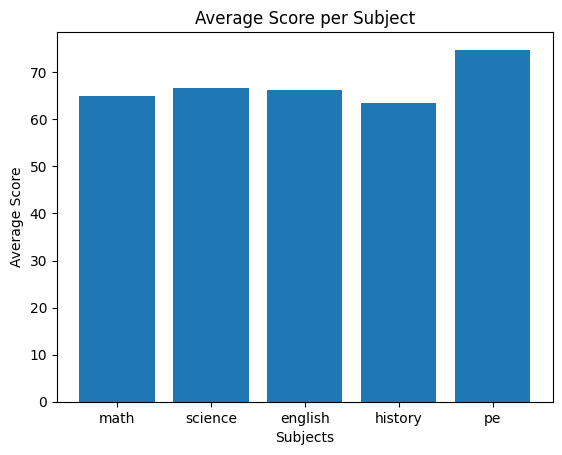

In [70]:
import matplotlib.pyplot as plt

avg_scores = df[subject_cols].mean()

plt.bar(subject_cols, avg_scores)
plt.title("Average Score per Subject")
plt.xlabel("Subjects")
plt.ylabel("Average Score")

plt.savefig("plot1_bar.png")
plt.show()

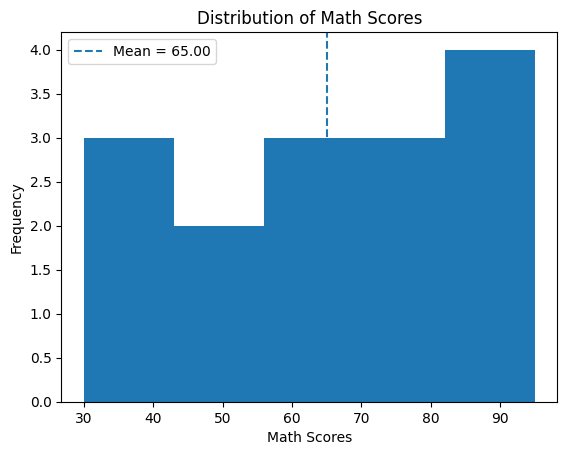

In [71]:
plt.hist(df['math'], bins=5)

mean_math = df['math'].mean()
plt.axvline(mean_math, linestyle='dashed', label=f"Mean = {mean_math:.2f}")

plt.title("Distribution of Math Scores")
plt.xlabel("Math Scores")
plt.ylabel("Frequency")
plt.legend()

plt.savefig("plot2_histogram.png")
plt.show()

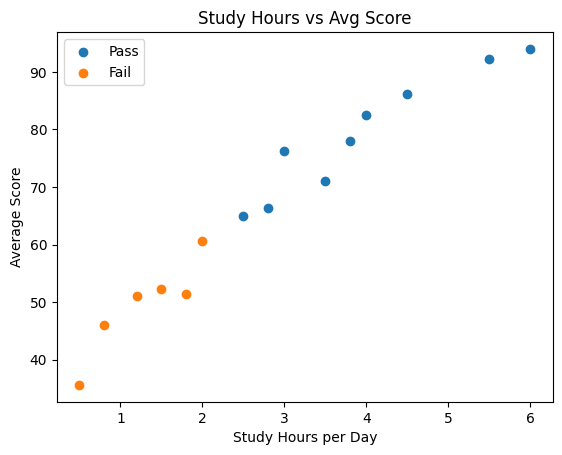

In [72]:
pass_students = df[df['passed'] == 1]
fail_students = df[df['passed'] == 0]

plt.scatter(pass_students['study_hours_per_day'], pass_students['avg_score'], label="Pass")
plt.scatter(fail_students['study_hours_per_day'], fail_students['avg_score'], label="Fail")

plt.title("Study Hours vs Avg Score")
plt.xlabel("Study Hours per Day")
plt.ylabel("Average Score")
plt.legend()

plt.savefig("plot3_scatter.png")
plt.show()

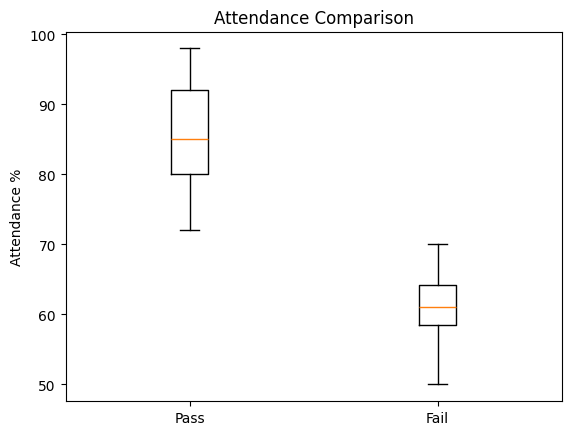

In [73]:
pass_attendance = df[df['passed'] == 1]['attendance_pct'].tolist()
fail_attendance = df[df['passed'] == 0]['attendance_pct'].tolist()

plt.boxplot([pass_attendance, fail_attendance], tick_labels=['Pass', 'Fail'])

plt.title("Attendance Comparison")
plt.ylabel("Attendance %")

plt.savefig("plot4_box.png")
plt.show()

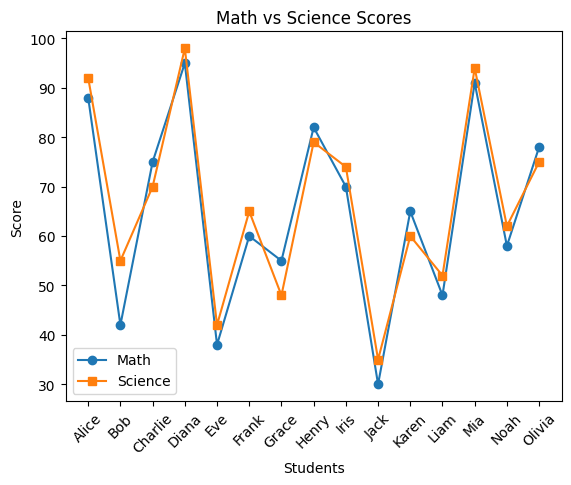

In [74]:
plt.plot(df['name'], df['math'], marker='o', label='Math')
plt.plot(df['name'], df['science'], marker='s', label='Science')

plt.xticks(rotation=45)

plt.title("Math vs Science Scores")
plt.xlabel("Students")
plt.ylabel("Score")
plt.legend()

plt.savefig("plot5_line.png")
plt.show()

In [75]:
import seaborn as sns
import matplotlib.pyplot as plt

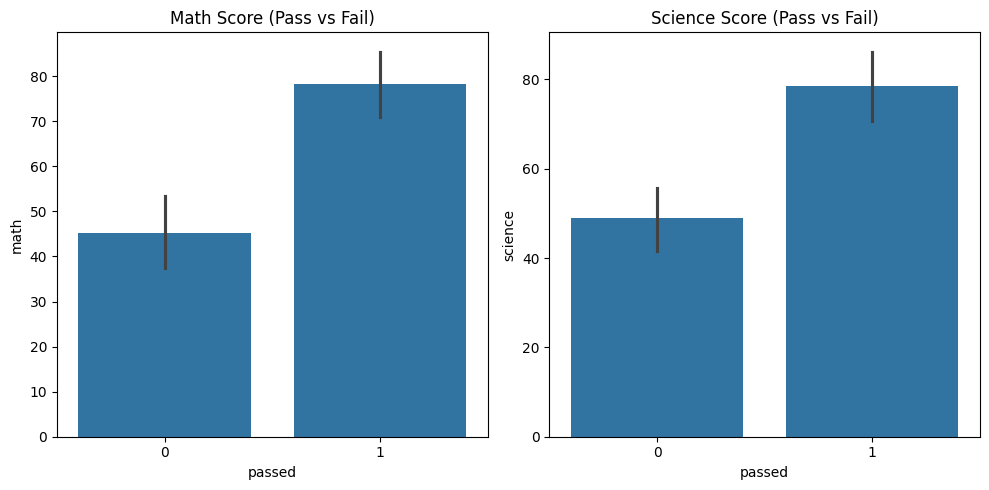

In [76]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))

# Math plot
sns.barplot(data=df, x='passed', y='math', ax=ax1)
ax1.set_title("Math Score (Pass vs Fail)")

# Science plot
sns.barplot(data=df, x='passed', y='science', ax=ax2)
ax2.set_title("Science Score (Pass vs Fail)")

plt.tight_layout()
plt.savefig("plot6_seaborn_bar.png")
plt.show()

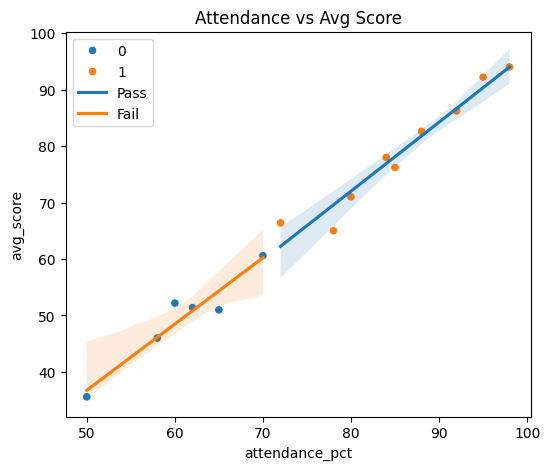

In [77]:
plt.figure(figsize=(6,5))

# Scatter plot
sns.scatterplot(data=df, x='attendance_pct', y='avg_score', hue='passed')

# Regression line for Pass
sns.regplot(data=df[df['passed']==1],
            x='attendance_pct', y='avg_score',
            scatter=False, label='Pass')

# Regression line for Fail
sns.regplot(data=df[df['passed']==0],
            x='attendance_pct', y='avg_score',
            scatter=False, label='Fail')

plt.title("Attendance vs Avg Score")
plt.legend()

plt.savefig("plot7_seaborn_scatter.png")
plt.show()

In [78]:
# Seaborn was easier than Matplotlib because it automatically creates better-looking graphs.
# It required less code for styling and grouping data.
# Matplotlib gives more control, but needs more manual work.

In [79]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [80]:
# Features (X) and Target (y)
X = df[['math', 'science', 'english', 'history', 'pe', 'attendance_pct', 'study_hours_per_day']]
y = df['passed']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [81]:
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

# Training accuracy
train_pred = model.predict(X_train_scaled)
print("Training Accuracy:", accuracy_score(y_train, train_pred))

Training Accuracy: 1.0


In [82]:
y_pred = model.predict(X_test_scaled)

print("Test Accuracy:", accuracy_score(y_test, y_pred))

Test Accuracy: 1.0


In [83]:
names = df.loc[X_test.index, 'name']

for name, actual, pred in zip(names, y_test, y_pred):
    result = "✅ Correct" if actual == pred else "❌ Wrong"
    print(f"{name}: Actual={actual}, Predicted={pred} → {result}")

Jack: Actual=0, Predicted=0 → ✅ Correct
Liam: Actual=0, Predicted=0 → ✅ Correct
Alice: Actual=1, Predicted=1 → ✅ Correct


In [84]:
import numpy as np

coefficients = model.coef_[0]
features = X.columns

# Pair and sort
feature_importance = sorted(
    zip(features, coefficients),
    key=lambda x: abs(x[1]),
    reverse=True
)

print("Feature Importance:")
for feature, coef in feature_importance:
    print(f"{feature}: {coef:.4f}")

Feature Importance:
english: 0.8125
attendance_pct: 0.5219
study_hours_per_day: 0.4844
pe: 0.4750
math: 0.4379
science: 0.3230
history: 0.2629


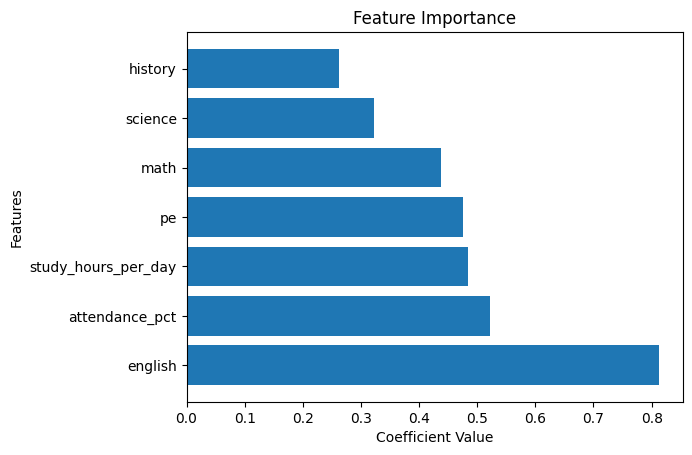

In [85]:
import matplotlib.pyplot as plt

features = [f for f, _ in feature_importance]
values = [v for _, v in feature_importance]

colors = ['green' if v > 0 else 'red' for v in values]

plt.barh(features, values)
plt.title("Feature Importance")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")

plt.savefig("plot8_feature_importance.png")
plt.show()

In [86]:
import pandas as pd

new_student = pd.DataFrame(
    [[75, 70, 68, 65, 80, 82, 3.2]],
    columns=['math', 'science', 'english', 'history', 'pe', 'attendance_pct', 'study_hours_per_day']
)

new_scaled = scaler.transform(new_student)

prediction = model.predict(new_scaled)
prob = model.predict_proba(new_scaled)

result = "Pass" if prediction[0] == 1 else "Fail"

print("Prediction:", result)
print("Probability:", prob)

Prediction: Pass
Probability: [[0.09203526 0.90796474]]
